#run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Pull data

In [1]:
from google.cloud import bigquery
import numpy as np
client = bigquery.Client()
import random
from sklearn.model_selection import train_test_split
# a
random.seed(100)
np.random.seed(100)

In [2]:
import pandas as pd
import re

pd.set_option('display.max_colwidth', None)
pd.set_option("display.max_rows", None)

In [3]:
#This query pulls the features (both embedding and non-embedding) into a single df for you.
sql = """
SELECT
    f.* EXCEPT (asdb_plan_key, post_mnths, first_prv_dt, last_prv_dt, index_dt)
    , e.* EXCEPT (individual_id)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features` AS f
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_embeddings` AS e
        ON f.asdb_member_key = e.individual_id
WHERE 1=1
    AND NOT asdb_plan_key IN (33, 54)
    AND post_mnths >= 6
"""
df = client.query(sql).to_dataframe() 
df.head()
# df = pd.read_csv('data.csv')


,asdb_member_key,coa_population_category,coa_population_group,sum_ed_visits_yr1,ed_flag_yr1,sum_avoidable_yr1,sum_unnecessary_yr1,sum_preventable_yr1,low_sev_ed_visits_yr1,low_med_sev_ed_visits_yr1,...,emb246,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255
0,451391023,TANF,TANF/CHIP,2,1,0,0,0,0,0,...,-0.028434,0.274153,0.044573,-0.562841,-1.072046,1.026511,0.272165,0.479589,-0.680143,-0.402234
1,560051880,TANF,TANF/CHIP,0,0,0,0,0,0,0,...,-0.197793,-0.219819,0.062923,-0.801985,-0.487045,1.328310,0.141931,-0.273699,-0.759644,-0.294348
2,351665241,TANF,TANF/CHIP,1,1,0,0,0,0,0,...,0.640426,0.851515,0.971892,-0.089534,-1.035656,1.051183,0.485108,-0.646896,-0.914190,-0.082131
3,480552275,TANF,TANF/CHIP,0,0,0,0,0,0,0,...,0.765829,0.745395,1.092559,-0.681084,-0.767807,1.162511,0.194243,-0.802691,-0.858413,0.029203
4,500229260,Expansion,Expansion,1,1,0,0,0,0,0,...,0.008428,0.270926,-0.007365,-0.915459,-1.417536,0.663393,-0.215011,-0.096427,-0.745830,-0.707759


In [5]:
df.shape
#2,542,308 members who qualify with 564 features we are exploring

(2542308, 561)

In [6]:
#This query pulls the outcome variable we will be training to - acute in-patient (IP) stay (0=no, 1=yes) in the 6 months post-index date
#Think about methods to oversample or undersample if needed to achieve a better balance since <3% of our training set has an IP stay
sql = """
SELECT
    asdb_member_key
    , acute_ip_flag
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_outcome_ip` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome = client.query(sql).to_dataframe() 
outcome.head()

,asdb_member_key,acute_ip_flag
0,72334360,0
1,480243965,0
2,440716448,0
3,451022969,0
4,461235869,0


In [7]:
print(outcome.shape)
print(outcome['acute_ip_flag'].value_counts())

(2542308, 2)
acute_ip_flag
0    2467704
1      74604
Name: count, dtype: Int64


### Data Preprocessing

In [8]:
#You will have NAs for the Transformer embedding features; 
#please set those to 0. Review the other NAs with me so I can either fix them upstream or instruct you how to set the NA value for downstream use
#This step is critical to document and do well - we always encounter NAs in servicing (where model is used) 
#Replicating what we do to prep NAs for training for servicing helps to prevent concept drift and poor servicing performance

na_counts = df.isna().sum()
# # Testing isna:
# print(na_counts[na_counts>0])
# print(df[df["food_access"].isna()]["food_access"])

# For numeric features
numeric_summary = df.describe()
numeric_summary.head()

non_numeric_summary = df.select_dtypes(include=["object","category"]).describe()
non_numeric_summary.head()


,coa_population_category,coa_population_group,gender,ethnicity_code,primarylanguage_desc,urbsubr
count,2542308,2542308,2542308,2542308,2542308,2540048
unique,17,8,3,104,131,3
top,TANF,TANF/CHIP,F,ETHN0001,ENGLISH,R
freq,1302580,1407108,1367262,794083,1788816,1117016


In [9]:
summary = pd.concat([na_counts.rename("NA Counts"), numeric_summary.transpose(), non_numeric_summary.transpose()],axis=1)
# display(summary)

In [10]:
# Replace NA values with 0 for embedding features
from pandas.api.types import is_datetime64_any_dtype as is_datetime
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df.columns if re.match(emb_pattern ,col)]
df[emb_col] = df[emb_col].fillna(0)

# TODO: Change or remove, this replaces all NA with 0 for correlation to work
        
# print(df.dtypes)
for c in df.columns: 
    dt = df[c].dtype
    if is_integer(dt) or is_float(dt):
        df[c]=df[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df[c]= df[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)
    
# na_counts = df.isna().sum()
# # Testing isna:
# print(na_counts[na_counts>0])

In [11]:
_, df_downsampled = train_test_split(df, test_size=0.01, random_state = 100) # arbitrary random state 
print(df_downsampled.shape)

(25424, 561)


In [12]:
# Find the number of distinct values for each column and display them all entirely - for testing
distinct_values = df.nunique().sort_values()

In [13]:
# print(distinct_values.sort_values()[distinct_values < 20].index.tolist())
distinct_values.to_csv("distinct_values.csv")

In [14]:
#  0 := categorical, 1 := continuous, 2 := binary
# Commented out low variance / low proportion of the most frequent value for each feature


nem_to_type = {
    # 'narc':0, # Errors if pointbiserialr ;; 1 value
    # 'otc_fills_yr2': 0, # Errors if pointbiserialr ;; 1 value
    # 'otc_fills_yr1':0,  # Errors if pointbiserialr ;; 1 value
    'COP':2, 
    'sleep_apnea':2, 
    'spinal_inj':2,
    'back':2,
    'substance':2,
    'ALC':2,
    'bipolar':2,
    'psychoses':2,
    'EDO':2, 
    'SCA':2, 
    'DIA':2, 
    'DEP':2, 
    'abdominal_pain':2, 
    'OST':2, 
    'AID':2, 
    'IDA':2, 
    'ANX':2, 
    'DEM':2, 
    # 'CYS':2, ###
    'autoimmune':2, 
    'MOH':2, 
    'HEM':2, 
    'esrd':2, 
    'HepC':2, 
    'HYP':2, 
    'HYC':2, 
    'immune':2, 
    'intel_dsblty':2, 
    'meta_cancer':2, 
    'liver_dis':2, 
    'MSS':2, 
    'OBE':2, 
    'oud':2, 
    'liver_other':2, 
    'paralysis':2, 
    'PAR':2, 
    # 'PUD':0,  # Errors if pointbiserialr 
    'hmd':2, 
    'PVD':2, 
    'CRO':2, 
    'AST':2, 
    'EPL':2, 
    'low_med_sev_ed_flag_yr2':2, 
    'med_high_sev_ed_flag_yr2':2, 
    'high_sev_ed_flag_yr2':2, 
    'acute_ip_flag_yr1':2, 
    'CHO':2,
    # 'burns':2, ###
    'acute_ip_flag_yr2':2, 
    'cad':2, 
    'Cancer':2, 
    'ed_flag_yr2':2, 
    'high_sev_ed_flag_yr1':2, 
    'med_sev_ed_flag_yr2':2, 
    'AUT':2, 
    'med_high_sev_ed_flag_yr1':2, 
    'low_med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr1':2, 
    'CBD':2, 
    'CHF':2, 
    'CRF':2, 
    'VNA':2, 
    'CHD':2, 
    'ed_flag_yr1':2, 
    'med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr2':2, 
    'urbsubr':0, 
    'gender':0, 
    # 'cms_prost_cancer_scrn':0, ###
    # 'cms_hpv_scrn':0, ###
    # 'cms_cvd_scrn':0, ###
    # 'cms_lung_cancer_scrn':0, ###
    # 'cms_pelvic':0, # 7/2/24 removed
    'coa_population_group':0, 
    # 'cms_pap':0, ###
    # 'cms_t2d_scrn':0, ###
    # 'cms_bone_scrn':0, # 7/2/24 removed
    # 'cms_alc_scrn':0, ###
    # 'cms_ibt_cvd':0, ###
    # 'cms_col_scrn':0, # 7/2/24 removed
    # 'index_dt':0, 
    # 'cms_ibt_obese':0, ###
    'cms_flu_vax':0, 
    # 'cms_pneum_vax':0, # 7/2/24 removed
    # 'cms_dep_scrn':0, # 7/2/24 removed
    'tenure_yr2':1, # either 
    'tenure_yr1':1, # either
    'cms_hepb_vax':0,
    # 'low_sev_ed_visits_yr2':0, # 7/2/24 removed
    'coa_population_category':0, 
    # 'cms_mam_scrn':0, # 7/2/24 removed
    'low_sev_ed_visits_yr1':1,
    'sum_acute_ip_admits_yr2':1,
    'sum_acute_ip_admits_yr1':1,
    # 'cms_tobacco':0,# 7/2/24 removed
    'low_med_sev_ed_visits_yr2':1, 
    # 'cms_t2d_train':0, # 7/2/24 removed
    'sum_preventable_yr2':1, 
    # 'cms_hepb_scrn':0, ###
    'sum_preventable_yr1':1, 
    'major_chronic_cnt':1, 
    'low_med_sev_ed_visits_yr1':1,
    'sum_ob':1, 
    'sum_unnecessary_yr2':1, 
    'sum_chol_lab':1, 
    # 'cms_nutrition':0,  # 7/2/24 removed
    'coe_anesth_clm_yr2':1, 
    'sum_a1c_lab':1, 
    'sum_unnecessary_yr1':1, 
    'sum_avoidable_yr2':1, 
    'gpi2_cnt_yr1':1, 
    'high_sev_ed_visits_yr2':1,
    'gpi2_cnt_yr2':1, 
    'ms_brand_fills_yr2':1, 
    'coe_anesth_clm_yr1':1, 
    'med_sev_ed_visits_yr2':1, 
    'cms_sti_scrn':0, 
    'med_high_sev_ed_visits_yr2':1, 
    'high_sev_ed_visits_yr1':1, 
    'ms_brand_fills_yr1':1, 
    'sum_avoidable_yr1':1, 
    'inhaled_steroid_scripts_yr2':1, 
    'med_high_sev_ed_visits_yr1':1, 
    'med_sev_ed_visits_yr1':1, 
    'inhaled_steroid_scripts_yr1':1, 
    'obs_clm_yr2':1,
    'gpi4_cnt_yr2':1,
    'gpi4_cnt_yr1':1,
    'obs_clm_yr1':1, 
    'sum_dme':1, 
    'antianginal_agent_scripts_yr2':1, 
    'mail_order_fills_yr2':1, 
    'branded_generic_fills_yr2':1, 
    'gpi_cnt_yr1':1,
    'gpi_cnt_yr2':1,
    'adi_score':1, 
    'sdi_score':1, 
    'antianginal_agent_scripts_yr1':1, 
    # 'ethnicity_code', 
    'sum_ed_visits_yr2':1,
    'mail_order_fills_yr1':1,
    'uc_clm_yr2':1, 
    'calcium_channel_blk_scripts_yr2':1,
    'antianxiety_scripts_yr2':1, 
    'beta_blocker_scripts_yr2':1, 
    'sum_ed_visits_yr1':1, 
    'branded_generic_fills_yr1':1,
    'coe_maternity_clm_yr2':1,
    'sum_chemo':1, 
    'agenbr':1, 
    'uc_clm_yr1':1,
    'calcium_channel_blk_scripts_yr1':1,
    'coe_maternity_clm_yr1':1,
    'diuretic_scripts_yr2':1,
    'primarylanguage_desc':0, 
    'beta_blocker_scripts_yr1':1, 
    'antianxiety_scripts_yr1':1,
    'antihypertensive_scripts_yr2':1,
    'ndc_cnt_yr1':1, 
    'ndc_cnt_yr2':1, 
    'lipid_lowering_scripts_yr2':1,
    'diuretic_scripts_yr1':1, 
    'coe_surg_clm_yr2':1, 
    'sum_acute_calc_los_yr1':1, 
    'sum_acute_calc_los_yr2':1,
    'sum_pcp':1, 
    'lipid_lowering_scripts_yr1':1, 
    'antihypertensive_scripts_yr1':1,
    'coe_surg_clm_yr1':1,
    'coe_mrx_clm_yr2':1,
    'antidepressant_scripts_yr2':1,
    'coe_mrx_clm_yr1':1, 
    'antipsychotic_scripts_yr2':1, 
    'anticonvulsant_scripts_yr2':1, 
    'antidiabetic_scripts_yr2':1, 
    'antidepressant_scripts_yr1':1, 
    'coe_radio_clm_yr2':1,
    'anticonvulsant_scripts_yr1':1, 
    'coe_radio_clm_yr1':1, 
    'emis_mrx_clm_yr2':1, 
    'coe_ltc_community_clm_yr1':1, 
    'emis_community_clm_yr1':1,
    'coe_ltc_community_clm_yr2':1, 
    'emis_community_clm_yr2':1, 
    'emis_radio_clm_yr1':1, 
    'emis_radio_clm_yr2':1, 
    'antipsychotic_scripts_yr1':1, 
    'antidiabetic_scripts_yr1':1, 
    'emis_mrx_clm_yr1':1,
    'coe_ip_hos_clm_yr2':1,
    'coe_ip_hos_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr2':1,
    'emis_pcp_clm_yr1':1,
    'emis_pcp_clm_yr2':1,
    'coe_phy_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr1':1,
    'inhaled_steroid_days_supply_yr2':1, 
    'coe_phy_clm_yr2':1, 
    'emis_ip_clm_yr2':1,
    'ss_brand_fills_yr2':1, 
    'emis_ip_clm_yr1':1, 
    'inhaled_steroid_days_supply_yr1':1, 
    'coe_eval_clm_yr2':1, 
    'coe_ltc_ins_clm_yr2':1, 
    'emis_ins_clm_yr2':1, 
    'sum_spec':1, 
    'coe_eval_clm_yr1':1, 
    'ss_brand_fills_yr1':1,
    'retail_fills_yr2':1, 
    'retail_fills_yr1':1, 
    'emis_ins_clm_yr1':1, 
    'coe_ltc_ins_clm_yr1':1, 
    'emis_spec_clm_yr2':1,
    'emis_spec_clm_yr1':1,
    'emis_ed_clm_yr2':1,
    'coe_lab_clm_yr2':1, 
    'generic_fills_yr2':1,
    'emis_ed_clm_yr1':1,
    # 'last_prv_dt':1, 
    # 'first_prv_dt':1,
    'coe_lab_clm_yr1':1,
    'maint_drug_fills_yr2':1,
    'emis_lab_clm_yr2':1,
    'formulary_fills_yr2':1,
    'emis_lab_clm_yr1':1, 
    'generic_fills_yr1':1, 
    'coe_op_hos_clm_yr2':1, 
    'formulary_fills_yr1':1,
    'emis_misc_clm_yr2':1,
    'maint_drug_fills_yr1':1,
    'coe_op_hos_clm_yr1':1, 
    'rx_claim_cnt_yr2':1, 
    'antianginal_agent_days_supply_yr2':1,
    'coe_mh_clm_yr2':1,
    'coe_mh_clm_yr1':1,
    'emis_misc_clm_yr1':1, 
    'coe_ltc_home_clm_yr2':1,
    'emis_home_clm_yr2':1,
    'antianginal_agent_days_supply_yr1':1, 
    'ltc_clm_yr2':1,
    'coe_ltc_home_clm_yr1':1,
    'emis_home_clm_yr1':1, 
    'emis_hh_clm_yr2':1, 
    'emis_hh_clm_yr1':1, 
    'ltc_clm_yr1':1, 
    'rx_claim_cnt_yr1':1, 
    'calcium_channel_blk_days_supply_yr2':1, 
    'sum_op_visits_yr2':1, 
    'sum_op_visits_yr1':1, 
    'coe_op_non_hos_clm_yr2':1,
    'emis_ambul_clm_yr2':1, 
    'water_quality':1, 
    'coe_op_non_hos_clm_yr1':1, 
    'calcium_channel_blk_days_supply_yr1':1, 
    'beta_blocker_days_supply_yr2':1,
    'emis_ambul_clm_yr1':1,
    'beta_blocker_days_supply_yr1':1, 
    'emis_mh_clm_yr2':1, 
    'emis_mh_clm_yr1':1, 
    'diuretic_days_supply_yr2':1, 
    'antianxiety_days_supply_yr2':1, 
    'lipid_lowering_days_supply_yr2':1, 
    'coe_other_clm_yr2':1, 
    'coe_other_clm_yr1':1,
    'antianxiety_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr2':1,
    'diuretic_days_supply_yr1':1, 
    'lipid_lowering_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr1':1, 
    'antipsychotic_days_supply_yr2':1,
    'antidepressant_days_supply_yr2':1,
    'antipsychotic_days_supply_yr1':1,
    'antidepressant_days_supply_yr1':1, 
    'anticonvulsant_days_supply_yr2':1, 
    'anticonvulsant_days_supply_yr1':1,
    'antidiabetic_days_supply_yr2':1, 
    'antidiabetic_days_supply_yr1':1, 
    'income_inequality':1, 
    'svi_score':1, 
    'days_supply_sum_yr2':1, 
    'zip_weight_avg_medinc':1,
    'days_supply_sum_yr1':1,
    'food_access':1, 
    'citizenship_index':1,
    'acs_social_risk_score':1, 
    'housing_desert':1, 
    'unemployment_index':1,
    'health_habits':1,
    'natural_disaster':1,
    'proactive_health':1,
    'housing_ownership':1, 
    'health_infra':1,
    'language_score':1, 
    'racial_diversity':1, 
    'housing_quality':1,
    'income_index':1,
    'education_index':1,
    'transport_access':1, 
    'disability_score':1,
    'technology_access':1,
    'poverty_score':1, 
    'social_isolation':1,
    'health_access':1,
    'csdi_social_risk_score':1,
     'asdb_member_key':1,
}

emb_dict = {f"emb{i}": 1 for i in range(256)}

col_to_type = emb_dict | nem_to_type
# Use col_to_type from now on


In [15]:
def print_value_distribution_by_percentage(df_column):
    value_counts = df_column.value_counts(normalize=True) * 100
    for value, percentage in value_counts.items():
        print(f"{value}: {percentage:.2f}%")

# print_value_distribution_by_percentage(df["low_sev_ed_visits_yr2"])

In [16]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df["coa_population_category"] = label_encoder.fit_transform(df["coa_population_category"])
df["coa_population_group"] = label_encoder.fit_transform(df["coa_population_group"])
df["gender"] = label_encoder.fit_transform(df["gender"])
df["primarylanguage_desc"] = label_encoder.fit_transform(df["primarylanguage_desc"])
df["urbsubr"] = label_encoder.fit_transform(df["urbsubr"])

In [17]:
from scipy.stats import pearsonr, f_oneway, pointbiserialr
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
# import numpy as np
import warnings
warnings.filterwarnings("error")

def cramers_v(x, y):
    crosstab = np.array(pd.crosstab(x,y))
    test_stat = chi2_contingency(crosstab)[0]
    num_observations = np.sum(crosstab)
    min_value = min(crosstab.shape)-1 # min of the cross table's rows and columns
    try:
        return np.sqrt(test_stat/(num_observations*min_value))
    except: return 0

In [18]:
pip install pingouin

Note: you may need to restart the kernel to use updated packages.


In [19]:
correlation_table = pd.DataFrame(index=list(col_to_type.keys()), columns=list(col_to_type.keys()))
correlation_table.shape

(534, 534)

In [20]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


### Creating Correlation Table (runtime several hours)

In [21]:
from tqdm import tqdm
'''
####### CODE FOR CREATING CORRELATION TABLE ########### ******** WITH ANOVA *******
'''


failed_categories = set()
warning_debug = set()
anova_type = set()

for i, col1 in enumerate(tqdm(correlation_table.columns, position = 0)):
    correlation_table.to_csv("correlation_table3.csv")
    
    for col2 in correlation_table.columns[i+1:]:
        
        if col1 == "asdb_member_key" or col2=="asdb_member_key": continue
        
        if col1 in col_to_type and col2 in col_to_type and col_to_type[col1]==1 and col_to_type[col2]==1 and not 'dt' in col1 and not 'dt' in col2: # IF BOTH CONTINUOUS
            try:
                correlation_table.loc[col1, col2] = correlation_table.loc[col2, col1] = pearsonr(df_downsampled[col1], df_downsampled[col2])[0]
            except Warning: 
                # print("Pearson", col1, col2)
                warning_debug.add(("Pearson",col1,col2))
        elif col1 in col_to_type and col2 in col_to_type and ((col_to_type[col1]==1 and col_to_type[col2]==0) or (col_to_type[col1]==0 and col_to_type[col2]==1)) and not 'dt' in col1 and not 'dt' in col2: # IF CONT + CAT
            try:
                # _, corr = f_oneway(df_downsampled[col1], df_downsampled[col2])  
                
                if df_downsampled[col2].dtype == 'object':
                    _, corr = f_oneway(*(group for _, group in df_downsampled.groupby(col2)[col1]))
                else:
                    _, corr = f_oneway(*(group for _, group in df_downsampled.groupby(col1)[col2]))
                
                correlation_table.loc[col1, col2] = correlation_table.loc[col2, col1] =1-corr 
            except Warning: 
                # print("Anova", col1, col2)
                warning_debug.add(("Anova",col1,col2))
            except: 
                print("Anova type error", col1, col2)
                anova_type.add((col1,col2))
        elif col1 in col_to_type and col2 in col_to_type and ((col_to_type[col1]==1 and col_to_type[col2]==0) or (col_to_type[col1]==0 and col_to_type[col2]==1) 
                                                              or (col_to_type[col1]==1 and col_to_type[col2]==2) or (col_to_type[col1]==2 and col_to_type[col2]==1)) and not 'dt' in col1 and not 'dt' in col2: # IF CONT + BINARY
            try:
                if col_to_type[col1]==1: # col1 is continuous
                    _, corr = pointbiserialr(df_downsampled[col2], df_downsampled[col1]) # MUST BE (BOOL, CONT) 
                else: # col2 is continuous
                    _, corr = pointbiserialr(df_downsampled[col1], df_downsampled[col2]) # MUST BE (BOOL, CONT) 
                correlation_table.loc[col1, col2] = correlation_table.loc[col2, col1] =corr
            except Warning: 
                # print("Biserial", col1, col2)
                warning_debug.add(("Biserial",col1,col2))
                
            
            
        elif col1 in col_to_type and col2 in col_to_type and ((col_to_type[col1]==0 or col_to_type[col1]==2) and (col_to_type[col2]==0 or col_to_type[col2]==2)) and not 'dt' in col1 and not 'dt' in col2: # IF BOTH ARE CAT or BIN
            correlation_table.loc[col1, col2] = correlation_table.loc[col2, col1] =cramers_v(df_downsampled[col1], df_downsampled[col2])  
            
        else:
            # print("cateogry failed", col1,col2)
            failed_categories.add((col1,col2))
        
correlation_table.to_csv("correlation_table3.csv")


100%|██████████| 534/534 [46:52<00:00,  5.27s/it]  


In [24]:
pip install fastcluster

Note: you may need to restart the kernel to use updated packages.


In [25]:
# correlation_table = correlation_table.fillna(0)
with pd.option_context("future.no_silent_downcasting", True):
    correlation_table = correlation_table.fillna(0).infer_objects(copy=False)
    
# print(correlation_table)
# correlation_table.to_csv("correlation_table2.csv")


In [26]:
graph_correlation_table = pd.DataFrame(pd.read_csv("correlation_table3.csv"))
# graph_correlation_table

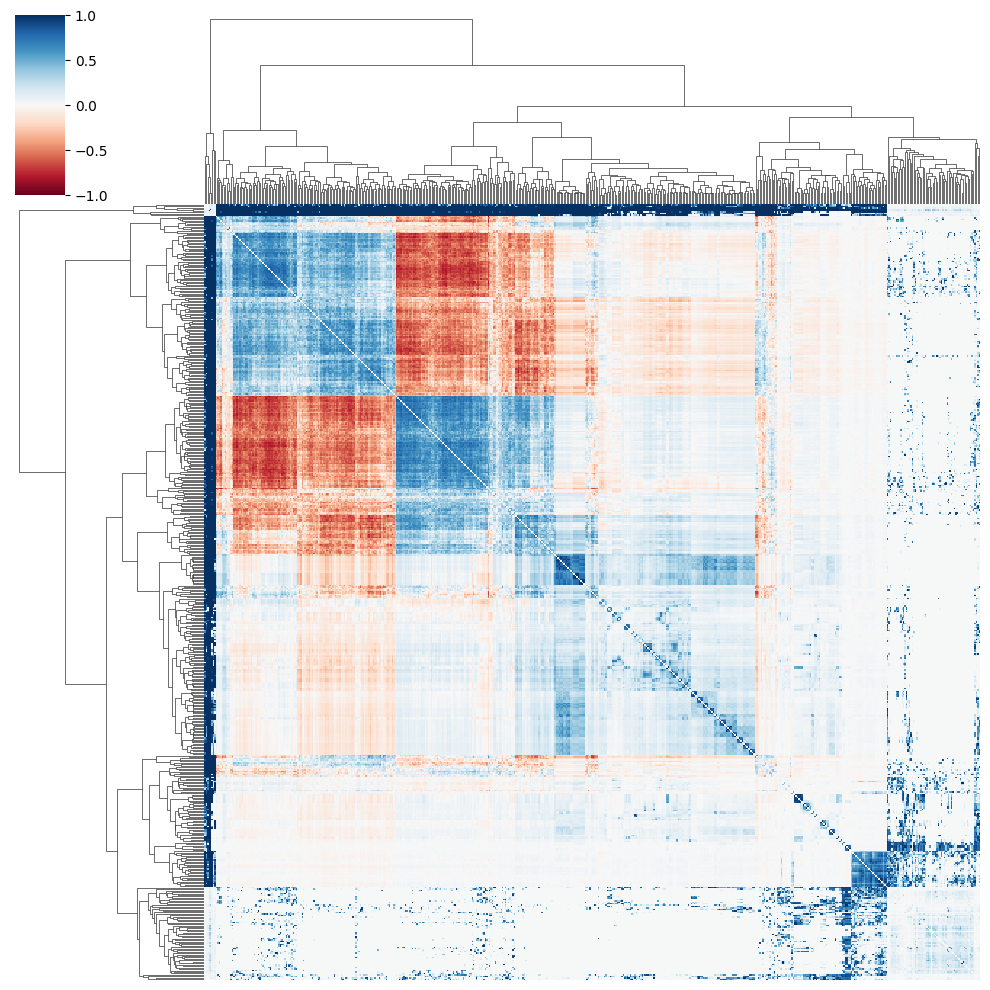

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# corr_unstacked = correlation_table.abs().unstack()
# corr_unstacked = corr_unstacked[corr_unstacked < 1]  # Exclude self-correlation
# most_corr_pairs = corr_unstacked.nlargest(20).index  # Select top 20 most correlate
# most_corr_vars = list(set([var for pair in most_corr_pairs for var in pair]))

# label_dict = {var: var if var in most_corr_vars else '' for var in correlation_table.index}


g = sns.clustermap(correlation_table, 
                   method = 'complete', 
                   cmap   = 'RdBu', 
                   annot  = False, 
                   annot_kws = {'size': 8}, fmt=".2f",
                   vmin =-1,
                   vmax = 1,
                   yticklabels=False,#[label_dict[var] for var in correlation_table.index], 
                   xticklabels=False#[label_dict[var] for var in correlation_table.columns]
                  )
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=60)
plt.show()


In [30]:
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster

Z = hierarchy.linkage(g.dendrogram_col.linkage, method='weighted', metric = "euclidean") # linkage matrix
# method = average, weighted, centroid, median?, 
# metric = euclidean, cityblock
# Looking for best mix of emb and non-emb


cluster = fcluster(Z, t=40, criterion = "distance")# criterion='maxclust'
# print(cluster)

column_name = ['cluster', 'variable']
assigned = pd.DataFrame(list(zip(cluster, df.columns.values.tolist())), columns=column_name) #list(zip(cluster, df.columns.values.tolist() ))
assigned = assigned.sort_values(by=['cluster'])

assigned

,cluster,variable
532,1,emb227
531,1,emb226
530,2,emb225
477,3,emb172
492,3,emb187
452,4,emb147
472,5,emb167
465,5,emb160
464,5,emb159
456,6,emb151


In [ ]:
#if you need to save to Big query, use the following cell
import google.auth
from google.auth import impersonated_credentials

credentials, project= google.auth.default()
client = bigquery.Client(credentials=credentials)
output_tbl ="anbc-hcb-dev.cm_medicaid_hcb_dev."#table name goes after the period

job_labels = {"costcenter": 13070, "owner": "eric_ma_aetna_com"}
load_config = bigquery.LoadJobConfig(labels=job_labels)
load_job = client.load_table_from_dataframe(
    dataframe = #[your_df_name_here],
    destination = output_tbl,
    job_config = load_config,
)

print(load_job.result())